In [10]:
import os
from style import (
    COLORS,
    LINESTYLES,
    LINEWIDTH,
    MARKERSIZE,
    latexify,
    CONFIDENCE_BAND_OPACITY,
    FCQUIC_COLOR,
    FCQUIC_FEC_COLOR,
    BASELINE_QUIC_COLOR,
    BASELINE_QUIC_LINESTYLE,
    FCQUIC_FEC_LINESTYLE,
    FCQUIC_LINESTYLE,
    BASELINE_TCP_COLOR,
    BASELINE_TCP_LINESTYLE,
    FCQUIC_MARKER,
    FCQUIC_FEC_MARKER,
    BASELINE_QUIC_MARKER,
    BASELINE_TCP_MARKER,
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [11]:
TEST="receivers"

In [12]:
# res_path = f"../tests/{TEST}/out/npf_out_receivers_0%_loss_uniform.csv"
res_path = f"../tests/{TEST}/out/npf_out_smaller_receivers_uniform.csv"

In [13]:
data_df = pd.read_csv(res_path)

topo_name = str(data_df["TOPO_CONF_NAME"][0]).replace('"', "")
poisson = str(data_df["POISSON"][0]).replace('"', "")
is_poisson = poisson == "true"
poisson_str = "poisson" if is_poisson else "uniform"
print(f"is poisson?: {is_poisson}")

data_df["CURRENT_TEST"] = data_df["CURRENT_TEST"].str.replace('"', "")

display(data_df)

q = data_df["y_LATENCY"].quantile(0.995)
display(f"Outlier threshold: {q}")
data_df = data_df[data_df["y_LATENCY"] < q]
data_df["y_LATENCY"] = data_df["y_LATENCY"].div(1000)
display(data_df)

num_clients = data_df["NUM_CLIENTS"].unique()
display(num_clients)

df_baseline = data_df[data_df["CURRENT_TEST"] == "QUIC"]
df_fcquic = data_df[data_df["CURRENT_TEST"] == "FCQUIC"]
df_fcquic_fec = data_df[data_df["CURRENT_TEST"] == "FCQUIC_FEC"]
df_tcp = data_df[data_df["CURRENT_TEST"] == "TCP"]

len_fcquic = len(df_fcquic)
len_baseline = len(df_baseline)
len_fcquic_fec = len(df_fcquic_fec)
len_tcp = len(df_tcp)

print(f"Baseline QUIC samples: {len_baseline}")
print(f"Baseline TCP samples: {len_tcp}")
print(f"FC-QUIC samples: {len_fcquic}")
print(f"FC-QUIC with FEC samples: {len_fcquic_fec}")

if len_fcquic < 0.5*len_baseline or len_fcquic_fec < 0.5*len_baseline:
    print("-------------------------------------- FCQUIC or FCQUIC_FEC probably bugged during the test!! --------------------------------------")

is poisson?: False


,index,build,test_index,TEST_DIR_NAME,TOPO_CONF_NAME,CURRENT_TEST,NUM_CLIENTS,INTERVAL,TEST_LENGTH,FALLBACK_DELAY,...,USE_SYSTEM_TIME,PER_CLIENT_LAT_RESULTS,RUN_LOGS_DIR_BASELINE,RUN_LOGS_DIR_TCP,RUN_LOGS_DIR_FCQUIC_NO_FEC,RUN_LOGS_DIR_FCQUIC_FEC,WORKDIR,CARGO_PATH,y_LATENCY,run_index
0,0,Local,0,receivers,smaller_receivers,FCQUIC_FEC,3,10,10,200,...,"""false""",False,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,5847.0,0
1,1,Local,0,receivers,smaller_receivers,FCQUIC_FEC,3,10,10,200,...,"""false""",False,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,6310.0,1
2,2,Local,0,receivers,smaller_receivers,FCQUIC_FEC,3,10,10,200,...,"""false""",False,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,40601.0,2
3,3,Local,0,receivers,smaller_receivers,FCQUIC_FEC,3,10,10,200,...,"""false""",False,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,40878.0,3
4,4,Local,0,receivers,smaller_receivers,FCQUIC_FEC,3,10,10,200,...,"""false""",False,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,5755.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69945,69945,Local,19,receivers,smaller_receivers,TCP,11,10,10,200,...,"""false""",False,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,5635.0,5825
69946,69946,Local,19,receivers,smaller_receivers,TCP,11,10,10,200,...,"""false""",False,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,5795.0,5826
69947,69947,Local,19,receivers,smaller_receivers,TCP,11,10,10,200,...,"""false""",False,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,5993.0,5827
69948,69948,Local,19,receivers,smaller_receivers,TCP,11,10,10,200,...,"""false""",False,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,5997.0,5828


'Outlier threshold: 12727.785000000033'

,index,build,test_index,TEST_DIR_NAME,TOPO_CONF_NAME,CURRENT_TEST,NUM_CLIENTS,INTERVAL,TEST_LENGTH,FALLBACK_DELAY,...,USE_SYSTEM_TIME,PER_CLIENT_LAT_RESULTS,RUN_LOGS_DIR_BASELINE,RUN_LOGS_DIR_TCP,RUN_LOGS_DIR_FCQUIC_NO_FEC,RUN_LOGS_DIR_FCQUIC_FEC,WORKDIR,CARGO_PATH,y_LATENCY,run_index
0,0,Local,0,receivers,smaller_receivers,FCQUIC_FEC,3,10,10,200,...,"""false""",False,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,5.847,0
1,1,Local,0,receivers,smaller_receivers,FCQUIC_FEC,3,10,10,200,...,"""false""",False,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,6.310,1
4,4,Local,0,receivers,smaller_receivers,FCQUIC_FEC,3,10,10,200,...,"""false""",False,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,5.755,4
5,5,Local,0,receivers,smaller_receivers,FCQUIC_FEC,3,10,10,200,...,"""false""",False,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,5.998,5
6,6,Local,0,receivers,smaller_receivers,FCQUIC_FEC,3,10,10,200,...,"""false""",False,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,5.491,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69945,69945,Local,19,receivers,smaller_receivers,TCP,11,10,10,200,...,"""false""",False,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,5.635,5825
69946,69946,Local,19,receivers,smaller_receivers,TCP,11,10,10,200,...,"""false""",False,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,5.795,5826
69947,69947,Local,19,receivers,smaller_receivers,TCP,11,10,10,200,...,"""false""",False,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,5.993,5827
69948,69948,Local,19,receivers,smaller_receivers,TCP,11,10,10,200,...,"""false""",False,./logs/9_baseline,./logs/9_tcp,./logs/9_fcquic_no_fec,./logs/9_fcquic_fec,/home/corentin/fcquic_applications_master_thes...,/home/corentin/.cargo/bin/cargo,5.997,5828


array([ 3,  5,  7,  9, 11])

Baseline QUIC samples: 16847
Baseline TCP samples: 17570
FC-QUIC samples: 17526
FC-QUIC with FEC samples: 17657


In [14]:
def get_mean_std_grouped_for_df(df):
    grouped = df[["NUM_CLIENTS", "y_LATENCY"]].groupby("NUM_CLIENTS").agg(['mean', 'std', 'count'])
    # mean = grouped.mean(numeric_only=True)
    # std = grouped.std(numeric_only=True)
    # count = grouped.count()
    grouped = grouped.droplevel(axis=1, level=0).reset_index()
    grouped["ci"] = 1.96 * grouped["std"] / np.sqrt(grouped["count"])
    grouped["ci_lower"] = grouped["mean"] - grouped["ci"]
    grouped["ci_upper"] = grouped["mean"] + grouped["ci"]
    return grouped

In [15]:
baseline_grouped = get_mean_std_grouped_for_df(df_baseline)
fcquic_grouped = get_mean_std_grouped_for_df(df_fcquic)
fcquic_fec_grouped = get_mean_std_grouped_for_df(df_fcquic_fec)
tcp_grouped = get_mean_std_grouped_for_df(df_tcp)


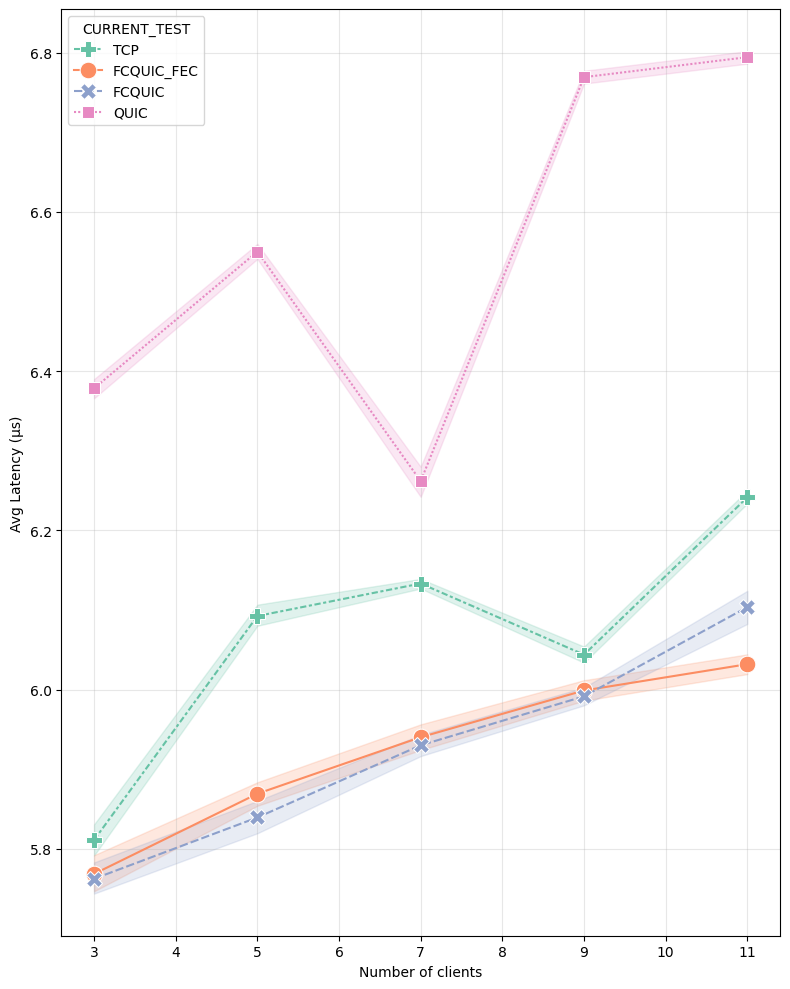

In [16]:
# latexify(nb_subplots_line=1, fig_height=8, fig_width=10)

plt.figure(figsize=(8, 10))
sns.lineplot(
    x="NUM_CLIENTS", y="y_LATENCY", hue="CURRENT_TEST",
    data=data_df, palette='Set2',
    style="CURRENT_TEST",  markers=True, markersize=12, dashes=True, alpha=1,
    hue_order=["TCP", "FCQUIC_FEC", "FCQUIC", "QUIC"],
    )
plt.xlabel("Number of clients")
plt.ylabel("Avg Latency (µs)")
# plt.ylim(bottom=5000)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# plt.xticks(num_clients)
# plt.savefig("clients_vs_lat_all.png", dpi=350, bbox_inches="tight",)
plt.show()

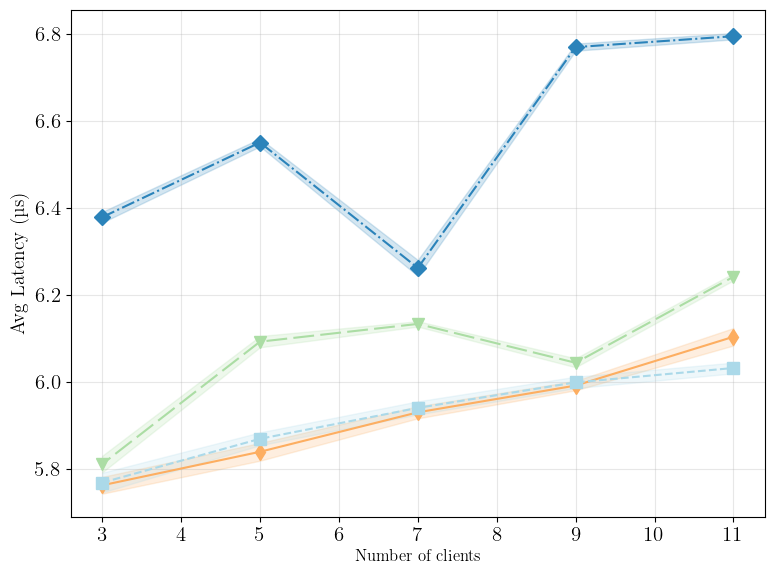

In [19]:





plt.figure(figsize=(8, 6))
latexify(nb_subplots_line=1, fig_height=8, fig_width=6)

# FCQUIC
x_fcquic = fcquic_grouped["NUM_CLIENTS"]
plt.plot(
    x_fcquic, fcquic_grouped["mean"],         
    label="FC-QUIC",
    color=FCQUIC_COLOR,
    linestyle=FCQUIC_LINESTYLE,
    marker=FCQUIC_MARKER,
    markersize=MARKERSIZE,
    lw=LINEWIDTH,
)
plt.fill_between(
    x_fcquic, fcquic_grouped["ci_lower"], fcquic_grouped["ci_upper"],
    color=FCQUIC_COLOR,
    alpha=CONFIDENCE_BAND_OPACITY
)

# FCQUIC-FEC
x_fcquic_fec = fcquic_fec_grouped["NUM_CLIENTS"]
plt.plot(
    x_fcquic_fec, fcquic_fec_grouped["mean"],         
    label="FC-QUIC with FEC",
    color=FCQUIC_FEC_COLOR,
    linestyle=FCQUIC_FEC_LINESTYLE,
    marker=FCQUIC_FEC_MARKER,
    markersize=MARKERSIZE,
    lw=LINEWIDTH,
)
plt.fill_between(
    x_fcquic_fec, fcquic_fec_grouped["ci_lower"], fcquic_fec_grouped["ci_upper"],
    color=FCQUIC_FEC_COLOR,
    alpha=CONFIDENCE_BAND_OPACITY
)

# Baseline QUIC
x_baseline = baseline_grouped["NUM_CLIENTS"]
plt.plot(
    x_baseline, baseline_grouped["mean"],         
    label="Baseline QUIC",
    color=BASELINE_QUIC_COLOR,
    linestyle=BASELINE_QUIC_LINESTYLE,
    marker=BASELINE_QUIC_MARKER,
    markersize=MARKERSIZE,
    lw=LINEWIDTH,
)
plt.fill_between(
    x_baseline, baseline_grouped["ci_lower"], baseline_grouped["ci_upper"],
    color=BASELINE_QUIC_COLOR,
    alpha=CONFIDENCE_BAND_OPACITY,
)

# TCP
x_tcp = tcp_grouped["NUM_CLIENTS"]
plt.plot(
    x_tcp, tcp_grouped["mean"],         
    label="Baseline TCP (+TLS)",
    color=BASELINE_TCP_COLOR,
    linestyle=BASELINE_TCP_LINESTYLE,
    marker=BASELINE_TCP_MARKER,
    markersize=MARKERSIZE,
    lw=LINEWIDTH,
)
plt.fill_between(
    x_tcp, tcp_grouped["ci_lower"], tcp_grouped["ci_upper"],
    color=BASELINE_TCP_COLOR,
    alpha=CONFIDENCE_BAND_OPACITY,
)

plt.xlabel("Number of clients", fontsize=12)
plt.ylabel("Avg Latency (µs)", fontsize=14)
# plt.ylim(bottom=5000)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 1000x2000 with 0 Axes>

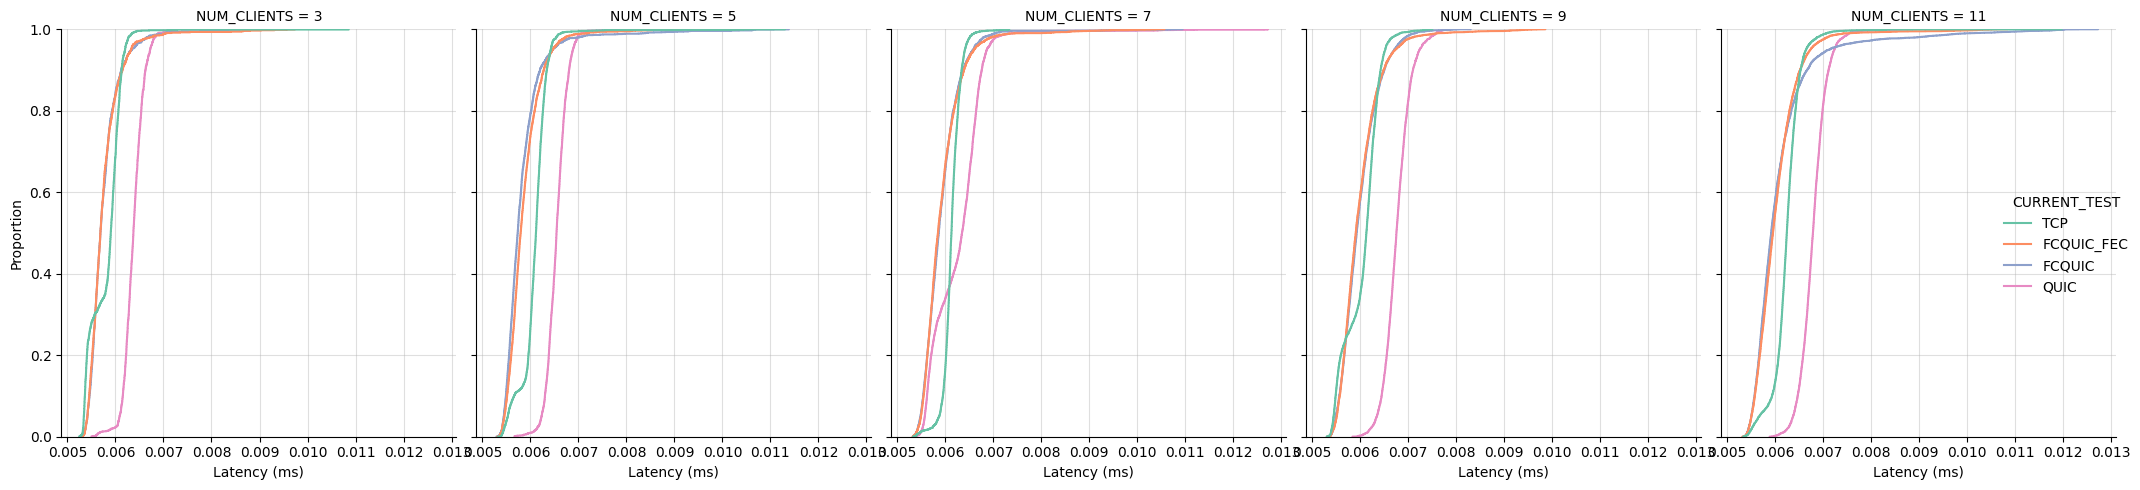

In [ ]:
# latexify(nb_subplots_line=1, fig_height=8, fig_width=10)


plt.figure(figsize=(10, 20))
grid = sns.displot(
    kind="ecdf",
    x=data_df["y_LATENCY"] / 1000,
    hue=data_df["CURRENT_TEST"],
    palette="Set2",
    col=data_df["NUM_CLIENTS"],
    hue_order=["TCP", "FCQUIC_FEC","FCQUIC", "QUIC"],
    height=5,
    aspect=0.8,
)

grid.set_axis_labels("Latency (ms)", "Proportion")
for _, ax in grid.axes_dict.items():
    ax.grid(True, alpha=0.4)
# plt.grid(True, alpha=0.3)

plt.tight_layout()
# plt.xlim(left=0)
# plt.savefig("cdfs_clients_all.png", dpi=350, bbox_inches="tight",)
plt.show()